# OLS Regrssor

### Jane Dalessio

In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

### Basic Data Inspection

In [11]:
seoul_bike_data = pd.read_csv("SeoulBikeData.csv", encoding = "unicode_escape")
seoul_bike_data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


### Separate the Date Column

In [14]:
seoul_bike_data["Date"] = pd.to_datetime(seoul_bike_data["Date"], format="%d/%m/%Y")
seoul_bike_data["Month"] = seoul_bike_data["Date"].dt.month
seoul_bike_data["Day_of_week"] = seoul_bike_data["Date"].dt.dayofweek  # 0 = Monday, 6 = Sunday
 
seoul_bike_data = seoul_bike_data.drop(columns=["Date"])
seoul_bike_data.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Month,Day_of_week
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4


### Encode Binary String Columns

In [20]:
seoul_bike_data["Holiday"] = seoul_bike_data["Holiday"].map({"No Holiday": 0, "Holiday": 1})
seoul_bike_data["Functioning Day"] = seoul_bike_data["Functioning Day"].map({"No": 0, "Yes": 1})

### Separate Features and Target

In [49]:
target_col = "Rented Bike Count"
y = seoul_bike_data[target_col]
X = seoul_bike_data.drop(columns=[target_col])
X = X.drop(columns=["Seasons"])
print("Features used:")
print(X.columns.tolist())

Features used:
['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Holiday', 'Functioning Day', 'Month', 'Day_of_week']


### Time-based Train/test Split

In [52]:
# The dataset has 8,760 hourly rows = 365 days
# 9 months ≈ 273 days = 6,552 rows
split_index = 6552
 
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
 
print(f"\nTraining samples:  {len(X_train)}")
print(f"Testing samples:   {len(X_test)}")


Training samples:  6552
Testing samples:   2208


### Scale Features

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Cross-validate on Training Set

In [58]:
# OLS has no hyperparameters to tune, but CV still gives us a reliable estimate of in-sample generalization performance.
tscv = TimeSeriesSplit(n_splits=5)
ols = LinearRegression()
 
mse_scores = -cross_val_score(
    ols, X_train_scaled, y_train,
    cv=tscv, scoring="neg_mean_squared_error"
)
cv_rmse = np.sqrt(mse_scores)
 
print(f"\nCV RMSE per fold: {cv_rmse.round(2)}")
print(f"Mean CV RMSE:     {cv_rmse.mean():.2f}")
print(f"Std CV RMSE:      {cv_rmse.std():.2f}")
 


CV RMSE per fold: [115.93 511.99 600.5  617.21 708.8 ]
Mean CV RMSE:     510.88
Std CV RMSE:      207.12


### Fit on Full Training Set

In [61]:
ols.fit(X_train_scaled, y_train)
y_pred = ols.predict(X_test_scaled)
 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
 
print(f"\n--- Final OLS Test Results ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")


--- Final OLS Test Results ---
RMSE: 484.06
MAE:  348.06
R²:   0.4493


### Feature Importance via Coefficients


--- Feature Coefficients (sorted by magnitude) ---
                  Feature  Coefficient
          Temperature(°C)   345.850772
                     Hour   176.514591
              Humidity(%)  -172.500097
Dew point temperature(°C)    84.516433
             Rainfall(mm)   -69.475416
  Solar Radiation (MJ/m2)   -65.046099
          Functioning Day    61.160360
                  Holiday   -30.821748
         Wind speed (m/s)    27.951021
              Day_of_week   -15.604399
            Snowfall (cm)     9.134634
                    Month    -6.771015
         Visibility (10m)     5.013336


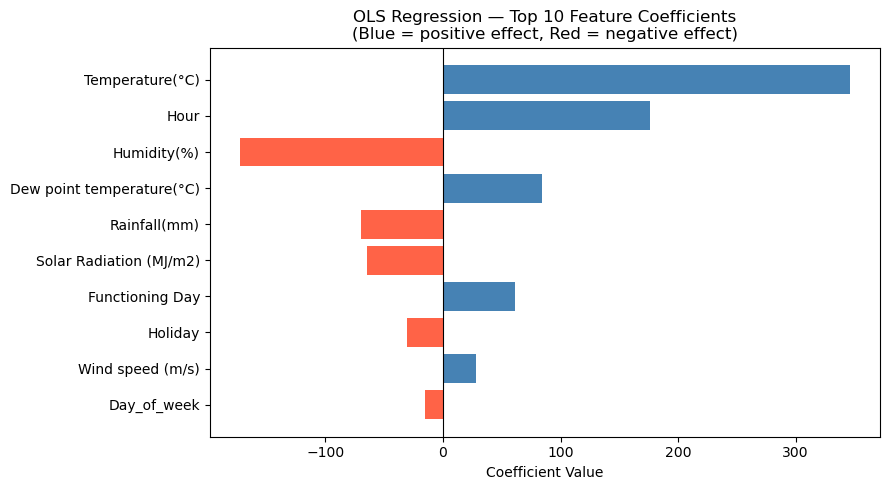

Saved coefficient plot to ols_coefficients.png


In [64]:
#This is OLS's main advantage over KNN where we can directly see which features drive demand and in which direction
feature_names = X.columns.tolist()
coefficients  = ols.coef_
 
coef_df = pd.DataFrame({
    "Feature":     feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient", key=abs, ascending=False)
 
print("\n--- Feature Coefficients (sorted by magnitude) ---")
print(coef_df.to_string(index=False))
 
# Plot top 10 coefficients
top10 = coef_df.head(10)
colors = ["steelblue" if c > 0 else "tomato" for c in top10["Coefficient"]]
 
plt.figure(figsize=(9, 5))
plt.barh(top10["Feature"], top10["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient Value")
plt.title("OLS Regression — Top 10 Feature Coefficients\n(Blue = positive effect, Red = negative effect)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("ols_coefficients.png", dpi=150)
plt.show()
print("Saved coefficient plot to ols_coefficients.png")
 